In [1]:
import re
import pandas as pd
import json
import os
os.chdir('..')

In [4]:
from transformer_lens import HookedTransformer, HookedTransformerConfig
import pickle
import torch
os.environ['CUDA_VISIBLE_DEVICES'] = '7'

In [5]:
def parse_training_log(file_path):
    """
    Parses a training log file to extract epoch, samples, step, and loss information.

    Args:
        file_path (str): The path to the log file.

    Returns:
        pandas.DataFrame: A DataFrame containing the parsed data with columns
                          ['Epoch', 'Samples', 'Step', 'Loss'].
                          Returns an empty DataFrame if no data is found.
    """
    # Regex to find lines with "Epoch", "Samples", "Step", and "Loss"
    # It captures the numerical value associated with each keyword.
    # (\d+) captures integers, ([\d.]+) captures floating-point numbers.
    pattern = re.compile(r"Epoch\s+(\d+)\s+Samples\s+(\d+)\s+Step\s+(\d+)\s+Loss\s+([\d.]+)")
    
    parsed_data = []

    try:
        with open(file_path, 'r') as f:
            for line in f:
                # Search for the pattern in each line
                match = pattern.search(line)
                if match:
                    # Extract captured groups and convert them to the correct type
                    epoch = int(match.group(1))
                    samples = int(match.group(2))
                    step = int(match.group(3))
                    loss = float(match.group(4))
                    
                    # Append the data as a dictionary to our list
                    parsed_data.append({
                        "Epoch": epoch,
                        "Samples": samples,
                        "Step": step,
                        "Loss": loss
                    })
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return pd.DataFrame()

    # Convert the list of dictionaries to a pandas DataFrame for nice formatting
    return pd.DataFrame(parsed_data)

In [46]:
from glob import glob
dataset_folder = 'corrected_splitopinion_typocorrected_gas_arrow'
lang = 'indo'
file_names = glob(f'logs/sft_full/{dataset_folder}/{lang}/**/*.log', recursive=True)
# Sort filenames based on creation date
file_names.sort(key=lambda x: os.path.getctime(x))

In [47]:
file_names

['logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_31415/3191021_Jum 10 Okt 2025 09:33:41  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_9584/3191024_Jum 10 Okt 2025 09:33:41  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_123/3191025_Jum 10 Okt 2025 09:33:41  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_2024/3191044_Jum 10 Okt 2025 09:33:41  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_777/3191022_Jum 10 Okt 2025 09:33:41  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_2024/3765601_Jum 10 Okt 2025 09:13:58  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_123/3765592_Jum 10 Okt 2025 09:13:58  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_9584/3765578_Jum 10 Okt 2025 09:13:58  UTC.log',
 'logs/sft_full/corrected_

In [48]:
file_names[-5:]

['logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_777/3103420_Sen 13 Okt 2025 03:59:21  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_2024/3103376_Sen 13 Okt 2025 03:59:21  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_777/3106772_Sen 13 Okt 2025 04:00:13  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_31415/3106746_Sen 13 Okt 2025 04:00:13  UTC.log',
 'logs/sft_full/corrected_splitopinion_typocorrected_gas_arrow/indo/seed_2024/3106745_Sen 13 Okt 2025 04:00:13  UTC.log']

In [49]:
training_df_dict = {}
for file_name in file_names[-3:]:
	training_df_dict[file_name] = parse_training_log(file_name)

In [50]:
dataset_path = f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_train_augmented_noreasoning.json'
with open(dataset_path, 'r') as f:
    data = json.load(f)
len(data)

2482

In [51]:
from math import ceil
batch_size = 16
num_of_steps_per_epoch = ceil(len(data) / batch_size)
num_of_steps_per_epoch

156

In [52]:
for file_name, training_df in training_df_dict.items():
	training_df['Step Total'] = (training_df['Epoch'] - 1) * num_of_steps_per_epoch + training_df['Step']
	print(training_df.head(2))

   Epoch  Samples  Step       Loss  Step Total
0      1       16     0  14.443421           0
1      1      176    10   0.546167          10
   Epoch  Samples  Step       Loss  Step Total
0      1       16     0  14.290888           0
1      1      176    10   0.434280          10
   Epoch  Samples  Step       Loss  Step Total
0      1       16     0  15.064424           0
1      1      176    10   0.338647          10


In [53]:
max_step = training_df_dict[file_names[-1]]['Step'].max()
max_step

np.int64(150)

In [54]:
training_df_dict[file_names[-1]].loc[(training_df_dict[file_names[-1]]['Step'] % 13 == 0) | (training_df_dict[file_names[-1]]['Step'] == max_step), :]

,Epoch,Samples,Step,Loss,Step Total
0,1,16,0,15.064424,0
13,1,2096,130,0.508490,130
15,1,2416,150,0.322260,150
16,2,16,0,0.242618,156
29,2,2096,130,0.303828,286
31,2,2416,150,0.207982,306
32,3,16,0,0.349408,312
45,3,2096,130,0.227085,442
47,3,2416,150,0.279274,462
48,4,16,0,0.222639,468


In [55]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_loss_with_epochs(df, extra_info="", mod_step=1):
    """
    Plots the training loss versus total steps, with vertical lines for epochs
    and an annotation for the final loss value.

    Args:
        df (pandas.DataFrame): DataFrame with 'Step Total', 'Loss', and 'Epoch' columns.
    """
    if df.empty or not all(col in df.columns for col in ['Step Total', 'Loss', 'Epoch']):
        print("DataFrame is empty or missing required columns.")
        return

    # Find the 'Step Total' values where a new epoch begins
    epoch_change_steps = df[df['Epoch'].diff() > 0]['Step Total'].tolist()
    
	# Step filtering, but always keep the first and last points
    df = df[(df['Step'] % mod_step == 0) | (df['Step'] == df['Step'].min()) | (df['Step'] == df['Step'].max())]

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(15, 3))

    # Plot the main Loss vs. Step Total curve
    plt.plot(df['Step Total'], df['Loss'], marker='.', linestyle='-', color='royalblue', label='Loss')

    # Add a vertical line for each epoch change
    for i, step in enumerate(epoch_change_steps):
        label = 'Start of New Epoch' if i == 0 else ""
        plt.axvline(x=step, color='crimson', linestyle='--', linewidth=1.5, label=label)
        
    # --- ✨ NEW: Annotate the final data point ---
    if not df.empty:
        # Get the coordinates of the last point
        last_step = df['Step Total'].iloc[-1]
        last_loss = df['Loss'].iloc[-1]
        
        # Format the text for the annotation
        annotation_text = f'Final Loss: {last_loss:.4f}'
        
        # Add the annotation to the plot
        plt.annotate(
            text=annotation_text,                 # The text to display
            xy=(last_step, last_loss),            # The (x, y) point to annotate
            xytext=(10, -30),                     # 10 points right, 30 points down from the point
            textcoords='offset points',           # Use 'offset points' for positioning
            ha='left',                            # Horizontal alignment
            va='top',                             # Vertical alignment
            arrowprops=dict(arrowstyle='->', color='black', shrinkB=5),
            bbox=dict(boxstyle='round,pad=0.4', fc='wheat', alpha=0.6) # Add a box for readability
        )
    # --- End of new section ---

    # --- Formatting ---
    plt.title(f'Training Loss vs. Total Steps ({extra_info})', fontsize=18)
    plt.xlabel('Total Steps', fontsize=14)
    plt.ylabel('Loss (Log Scale)', fontsize=14)
    
    plt.yscale('log')
    
    plt.legend()
    plt.tight_layout()

    plt.show()

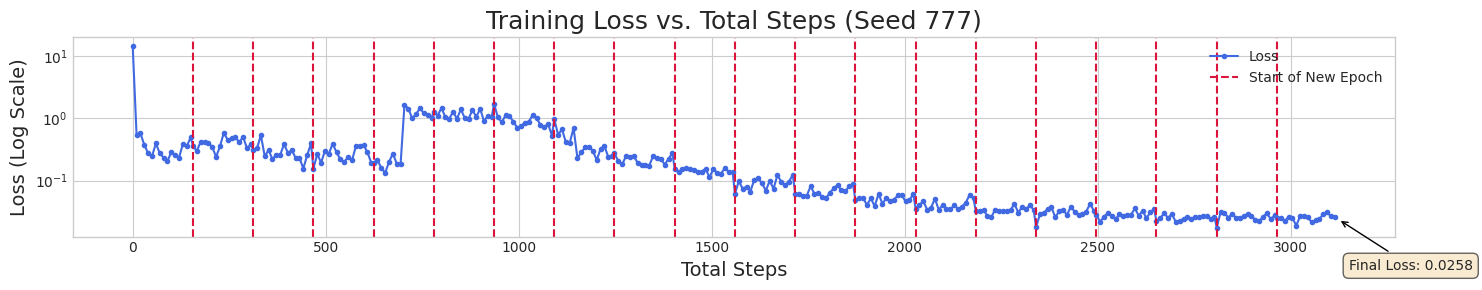

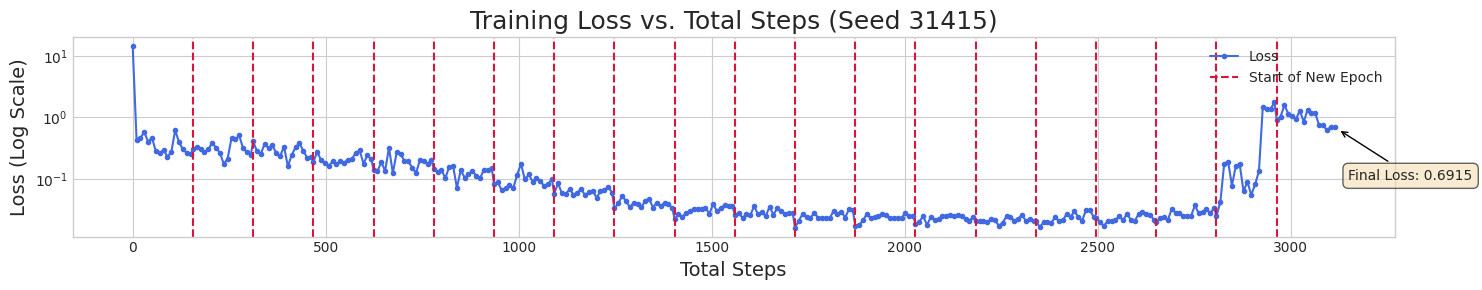

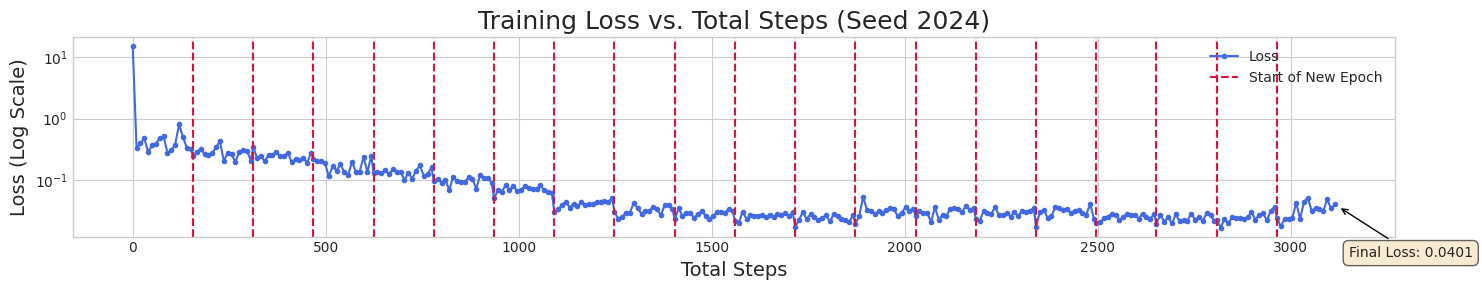

In [61]:
# Extract seed from filename
for file_name, training_df in training_df_dict.items():
	seed = re.search(r'seed_(\d+)', file_name)
	seed = seed.group(1) if seed else "unknown"
	plot_loss_with_epochs(training_df.iloc[0:, :], extra_info=f'Seed {seed}', mod_step=5)

## Debug Model

In [62]:
# Automatically select device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
def load_finetuned_model_lens_from_dir(dir: str, device: str = device) -> HookedTransformer:
    """
    Load a fine-tuned TransformerLens model from a specified directory.

    Args:
        dir (str): Directory containing the model files.
        device (str): Device to load the model onto.
    
    Returns:
        HookedTransformer: The loaded TransformerLens model.
    """
    with open(os.path.join(dir, 'model_config.pkl'), 'rb') as f:
        new_cfg_dict = pickle.load(f)
    new_cfg = HookedTransformerConfig.from_dict(new_cfg_dict)
    new_model = HookedTransformer(new_cfg)
    new_model.load_state_dict(torch.load(os.path.join(dir, 'model.pt'), map_location=device))
    return new_model

In [63]:
seeds = []
for file_name, training_df in training_df_dict.items():
	seed = re.search(r'seed_(\d+)', file_name)
	seed = seed.group(1) if seed else "unknown"
	seeds.append(seed)
seeds

['777', '31415', '2024']

In [64]:
model_paths = glob(f'outputs/modelsadamw/eap/{dataset_folder}/circuit-{lang}_finetune-{lang}/*/*/full_sft/*')
model_paths = [mp for mp in model_paths if any(seed in mp for seed in seeds)]
model_paths

['outputs/modelsadamw/eap/corrected_splitopinion_typocorrected_gas_arrow/circuit-indo_finetune-indo/seed_31415/aos_sequence_variants/full_sft/2025-10-13 13:15:31.129278_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20',
 'outputs/modelsadamw/eap/corrected_splitopinion_typocorrected_gas_arrow/circuit-indo_finetune-indo/seed_777/aos_sequence_variants/full_sft/2025-10-13 13:15:33.374247_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20',
 'outputs/modelsadamw/eap/corrected_splitopinion_typocorrected_gas_arrow/circuit-indo_finetune-indo/seed_2024/aos_sequence_variants/full_sft/2025-10-13 12:06:59.171479_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20']

In [65]:
models = {}
for mp in model_paths:
	# Make the key the seeds
	seed = re.search(r'seed_(\d+)', mp)
	seed = seed.group(1) if seed else "unknown"
	models[seed] = load_finetuned_model_lens_from_dir(mp, device=device)

In [ ]:
# --- Inspection Script ---
print("\n--- Starting Model Weight Inspection ---")

results_list = []

def inspect_weights(seed, tensor, name):
    """Calculates stats for a weight tensor and returns them as a dictionary."""
    stats = {
        'seed': seed,
        'layer': name,
        'mean': tensor.mean().item(),
        'std': tensor.std().item(),
        'max_abs': tensor.abs().max().item(),
        'has_nan': torch.isnan(tensor).any().item(),
        'has_inf': torch.isinf(tensor).any().item(),
    }
    return stats

for seed, model in models.items():
	# 1. Check Embedding and Unembedding
	results_list.append(inspect_weights(seed, model.embed.W_E, "embed.W_E"))
	results_list.append(inspect_weights(seed, model.unembed.W_U, "unembed.W_U"))

	# 2. Loop through all blocks
	for i in range(model.cfg.n_layers):
		block = model.blocks[i]
		
		# Attention weights
		results_list.append(inspect_weights(seed, block.attn.W_Q, f"blocks[{i}].attn.W_Q"))
		results_list.append(inspect_weights(seed, block.attn.W_K, f"blocks[{i}].attn.W_K"))
		results_list.append(inspect_weights(seed, block.attn.W_V, f"blocks[{i}].attn.W_V"))
		results_list.append(inspect_weights(seed, block.attn.W_O, f"blocks[{i}].attn.W_O"))
		
		# MLP weights
		results_list.append(inspect_weights(seed, block.mlp.W_gate, f"blocks[{i}].mlp.W_gate"))
		results_list.append(inspect_weights(seed, block.mlp.W_in, f"blocks[{i}].mlp.W_in"))
		results_list.append(inspect_weights(seed, block.mlp.W_out, f"blocks[{i}].mlp.W_out"))

# 3. Create and display the DataFrame
df = pd.DataFrame(results_list)

# Check for any NaNs or Infs across the entire model
if df['has_nan'].any() or df['has_inf'].any():
    print("\n‼️ CRITICAL WARNING: NaN or Inf values detected in the model!")
    print(df[(df['has_nan']) | (df['has_inf'])])


--- Starting Model Weight Inspection ---


In [42]:
# Sort by mean
df.sort_values(by='max_abs', ascending=False)

,seed,layer,mean,std,max_abs,has_nan,has_inf
228,777,blocks[8].attn.W_Q,-0.000053,0.037050,12.700196,False,False
398,2024,blocks[8].attn.W_Q,-0.000049,0.037051,12.699478,False,False
58,31415,blocks[8].attn.W_Q,-0.000050,0.037097,12.698011,False,False
284,777,blocks[16].attn.W_Q,-0.000111,0.046946,3.819070,False,False
454,2024,blocks[16].attn.W_Q,-0.000110,0.046954,3.812811,False,False
...,...,...,...,...,...,...,...
351,2024,blocks[1].attn.W_V,0.000035,0.007661,0.057850,False,False
181,777,blocks[1].attn.W_V,0.000040,0.007704,0.056112,False,False
174,777,blocks[0].attn.W_V,-0.000012,0.002191,0.023203,False,False
4,31415,blocks[0].attn.W_V,0.000003,0.002147,0.023093,False,False
